In [ ]:
# ============================================
# 1) Setup
# ============================================
!pip -q install sentencepiece emoji contractions nltk

import os, re, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import nltk
nltk.download("punkt")
nltk.download("stopwords")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Device: cpu


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================
# 2) Load data
# ============================================


DATA_DIR = "/content/drive/MyDrive/TASK01/data/"
TRAIN_CSV = os.path.join(DATA_DIR, "train_event_gap_reduced.csv")
DEV_CSV   = os.path.join(DATA_DIR, "dev_event_gap_reduced.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test_event_gap_reduced.csv")

train_df = pd.read_csv(TRAIN_CSV)
dev_df   = pd.read_csv(DEV_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", len(train_df), "Dev:", len(dev_df), "Test:", len(test_df))
print("Columns:", train_df.columns.tolist())

# Sanity checks (expected columns)
assert "tweet_text" in train_df.columns, "Missing column tweet_text"
assert "event_name" in train_df.columns, "Missing column event_name"

Train: 940 Dev: 217 Test: 146
Columns: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label']


In [ ]:
# ============================================
# 3) Fixed label mapping (REQUIRED)
# ============================================
LABEL2ID = {"earthquake": 0, "floods": 1, "hurricane": 2, "wildfires": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def map_label(x: str) -> int:
    x = str(x).strip().lower()
    if x not in LABEL2ID:
        raise ValueError(f"Unknown label: {x} (expected one of {list(LABEL2ID.keys())})")
    return LABEL2ID[x]

train_df["label_id"] = train_df["event_name"].apply(map_label)
dev_df["label_id"]   = dev_df["event_name"].apply(map_label)
test_df["label_id"]  = test_df["event_name"].apply(map_label)

# Sanity checks
assert set(train_df["label_id"].unique()).issubset({0,1,2,3})
assert set(dev_df["label_id"].unique()).issubset({0,1,2,3})
assert set(test_df["label_id"].unique()).issubset({0,1,2,3})

print("Label mapping used:", LABEL2ID)
print("\nTrain label counts:\n", train_df["label_id"].value_counts().sort_index())
print("\nDev label counts:\n", dev_df["label_id"].value_counts().sort_index())
print("\nTest label counts:\n", test_df["label_id"].value_counts().sort_index())

Label mapping used: {'earthquake': 0, 'floods': 1, 'hurricane': 2, 'wildfires': 3}

Train label counts:
 label_id
0    239
1    181
2    285
3    235
Name: count, dtype: int64

Dev label counts:
 label_id
0    60
1    41
2    60
3    56
Name: count, dtype: int64

Test label counts:
 label_id
0    35
1    28
2    45
3    38
Name: count, dtype: int64


In [ ]:
import nltk

# Make sure both punkt + punkt_tab exist (newer NLTK may require punkt_tab)
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# ============================================
# 4) Text preprocessing (research-level, stable)
# ============================================
import re
import string
import emoji as emoji_lib

URL_RE = re.compile(r"http\S+|www\S+", re.IGNORECASE)
MULTISPACE_RE = re.compile(r"\s+")
NONASCII_RE = re.compile(r"[^\x00-\x7F]+")

def preprocess_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = text.lower()

    # Remove URLs
    text = URL_RE.sub(" ", text)

    # Remove RT (retweet marker)
    text = re.sub(r"\brt\b", " ", text)

    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # Keep hashtag word but remove '#'
    text = text.replace("#", "")

    # Convert emojis to text form (:fire:, :earthquake:, etc.)
    text = emoji_lib.demojize(text)

    # Remove non-ascii characters
    text = NONASCII_RE.sub(" ", text)

    # Replace punctuation with space (keep ':' and '_' for emoji tokens)
    punct = string.punctuation.replace(":", "").replace("_", "")
    text = re.sub(f"[{re.escape(punct)}]", " ", text)

    # Simple regex tokenization (robust, backend-safe)
    tokens = re.findall(r"[a-z0-9_:\-]+", text)
    text = " ".join(tokens)

    # Normalize whitespace
    text = MULTISPACE_RE.sub(" ", text).strip()

    return text


# Apply preprocessing
train_df["clean_text"] = train_df["tweet_text"].apply(preprocess_text)
dev_df["clean_text"]   = dev_df["tweet_text"].apply(preprocess_text)
test_df["clean_text"]  = test_df["tweet_text"].apply(preprocess_text)

# Sanity checks
assert train_df["clean_text"].isnull().sum() == 0
print(train_df[["tweet_text","clean_text","event_name","label_id"]].sample(20, random_state=SEED))

                                            tweet_text  \
605  Feds Move to Crack Down on #HurricaneHarvey Sc...   
63   #India, #Srilanka have religious relationships...   
136  RT @thenews_intl: Magnitude 7.2 quake hits Ira...   
611  #SantaRosa Stands at a Crossroads After the #F...   
439  Mexicans shed tears for hundreds killed in #ea...   
670  Denver News Another earthquake hits central Me...   
382  no school for a week bc irma but 160 https://t...   
286  RT @thehill: Four Texas GOP lawmakers voted ag...   
444  Earthquake hits border of Iran and Iraq – in p...   
651  RT @ndtv: 'My house is full of blood': Over 14...   
334  Small towns fighting for more supplies after H...   
23   How Much Is #ClimateChange to Blame for Tropic...   
139  How To Help Iran-Iraq Border Earthquake Victim...   
493  It was a Mexico City office building. Now, aft...   
814  RT @myanmar_moi: Cyclone Mora wreaks havoc, cu...   
696  California newspaper editorials connected the ...   
30   Terror, C

In [ ]:
# ============================================
# 5) Imbalance diagnostics
# ============================================
counts = train_df["label_id"].value_counts().sort_index()
total = counts.sum()
freq = counts / total

print("Train distribution:")
for k in range(4):
    print(f"  {k} ({ID2LABEL[k]}): {counts.get(k,0)} ({freq.get(k,0):.2%})")

# Class weights (inverse frequency, normalized)
weights = (1.0 / (counts + 1e-9)).values
weights = weights / weights.sum() * 4.0  # average weight ~ 1
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("Class weights:", class_weights.detach().cpu().numpy())

Train distribution:
  0 (earthquake): 239 (25.43%)
  1 (floods): 181 (19.26%)
  2 (hurricane): 285 (30.32%)
  3 (wildfires): 235 (25.00%)
Class weights: [0.9578407  1.2647731  0.80324185 0.9741444 ]


In [ ]:
# ============================================
# 6) SentencePiece tokenizer training (custom, no pretrained)
# ============================================
import sentencepiece as spm

SP_DIR = "/content/drive/MyDrive/TASK01/models/task1b_custom_text/"
os.makedirs(SP_DIR, exist_ok=True)

sp_text_path = os.path.join(SP_DIR, "sp_train_text.txt")
with open(sp_text_path, "w", encoding="utf-8") as f:
    for t in train_df["clean_text"].tolist():
        f.write(t.replace("\n", " ") + "\n")

# Choose vocab size for low data (safe default)
VOCAB_SIZE = 4000
SP_MODEL_PREFIX = os.path.join(SP_DIR, "spm_bpe")

spm.SentencePieceTrainer.Train(
    input=sp_text_path,
    model_prefix=SP_MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=1.0,
    bos_id=1,
    eos_id=2,
    pad_id=0,
    unk_id=3
)

SPM_MODEL_PATH = SP_MODEL_PREFIX + ".model"
SPM_VOCAB_PATH = SP_MODEL_PREFIX + ".vocab"
print("Saved:", SPM_MODEL_PATH)

sp = spm.SentencePieceProcessor()
sp.load(SPM_MODEL_PATH)

# Sanity: encode/decode
sample = train_df["clean_text"].iloc[0]
ids = sp.encode(sample, out_type=int)
print("Sample:", sample)
print("Encoded length:", len(ids), "First 20 ids:", ids[:20])
print("Decoded:", sp.decode(ids[:50]))
print("Vocab size:", sp.get_piece_size())

Saved: /content/drive/MyDrive/TASK01/models/task1b_custom_text/spm_bpe.model
Sample: busy day chasing storm damage in richland co a mother and 4 yr old were sucked out of a home by winds or tornado
Encoded length: 29 First 20 ids: [2903, 638, 177, 108, 28, 429, 560, 30, 2176, 549, 421, 7, 2355, 101, 298, 165, 3964, 2033, 656, 174]
Decoded: busy day chasing storm damage in richland co a mother and 4 yr old were sucked out of a home by winds or tornado
Vocab size: 4000


In [ ]:
# ============================================
# 7) Dataset / Dataloader
# ============================================
MAX_LEN = 128

def encode_sp(text: str, max_len: int = MAX_LEN):
    ids = sp.encode(text, out_type=int)
    # add EOS at end (optional)
    ids = ids[: max_len - 1] + [sp.eos_id()]
    if len(ids) < max_len:
        ids = ids + [sp.pad_id()] * (max_len - len(ids))
    attn = [0 if i == sp.pad_id() else 1 for i in ids]
    return np.array(ids, dtype=np.int64), np.array(attn, dtype=np.int64)

class TweetSPDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label_id"].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x, attn = encode_sp(self.texts[idx])
        y = self.labels[idx]
        return torch.tensor(x), torch.tensor(attn), torch.tensor(y)

train_ds = TweetSPDataset(train_df)
dev_ds   = TweetSPDataset(dev_df)
test_ds  = TweetSPDataset(test_df)

# Weighted sampler for imbalance
train_labels = np.array(train_df["label_id"].values, dtype=np.int64)
class_count = np.bincount(train_labels, minlength=4)
class_w = 1.0 / (class_count + 1e-9)
sample_w = class_w[train_labels]
sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity batch
xb, ab, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, ab.shape, yb.shape)
print("Label sample:", yb[:10].tolist())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch shapes: torch.Size([32, 128]) torch.Size([32, 128]) torch.Size([32])
Label sample: [0, 3, 3, 0, 3, 2, 0, 0, 2, 0]


In [ ]:
# ============================================
# 8) Custom Transformer classifier (clear layers)
# ============================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        # x: [B, T, D]
        return x + self.pe[:, : x.size(1), :]

class AttnPool(nn.Module):
    """Learned attention pooling over token states."""
    def __init__(self, d_model: int):
        super().__init__()
        self.w = nn.Linear(d_model, 1)

    def forward(self, h, mask):
        # h: [B,T,D], mask: [B,T] 1=keep,0=pad
        scores = self.w(h).squeeze(-1)  # [B,T]
        scores = scores.masked_fill(mask == 0, -1e9)
        alpha = torch.softmax(scores, dim=1)  # [B,T]
        pooled = torch.bmm(alpha.unsqueeze(1), h).squeeze(1)  # [B,D]
        return pooled, alpha

class DisasterTransformer(nn.Module):
    def __init__(self, vocab_size: int, num_classes: int = 4,
                 d_model: int = 256, nhead: int = 8,
                 num_layers: int = 4, dim_ff: int = 512,
                 dropout: float = 0.2, max_len: int = MAX_LEN):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=sp.pad_id())
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.pool = AttnPool(d_model)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, num_classes)
        )

    def forward(self, x, attn_mask):
        # x: [B,T], attn_mask: [B,T] (1=keep,0=pad)
        h = self.emb(x)                 # [B,T,D]
        h = self.pos(h)
        # transformer expects key_padding_mask with True for PAD
        key_padding_mask = (attn_mask == 0)  # [B,T]
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)
        pooled, alpha = self.pool(h, attn_mask)
        logits = self.head(pooled)
        return logits, alpha

model = DisasterTransformer(vocab_size=sp.get_piece_size()).to(device)

# Sanity forward
xb, ab, yb = next(iter(train_loader))
logits, alpha = model(xb.to(device), ab.to(device))
print("Logits:", logits.shape, "Alpha:", alpha.shape)

/tmp/ipython-input-327/2931851454.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Logits: torch.Size([32, 4]) Alpha: torch.Size([32, 128])


In [ ]:
# ============================================
# 9) Loss + optimizer
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(weight=class_weights, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train loss 0.4693 acc 0.5979 | dev loss 0.1715 acc 0.8664 f1m 0.8656
  ✅ best model saved: /content/drive/MyDrive/TASK01/models/task1b_custom_text/best_custom_transformer.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train loss 0.0692 acc 0.9404 | dev loss 0.1028 acc 0.9401 f1m 0.9420
  ✅ best model saved: /content/drive/MyDrive/TASK01/models/task1b_custom_text/best_custom_transformer.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 04 | train loss 0.0104 acc 0.9915 | dev loss 0.1199 acc 0.9447 f1m 0.9430


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 05 | train loss 0.0063 acc 0.9957 | dev loss 0.1505 acc 0.9401 f1m 0.9390


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 06 | train loss 0.0022 acc 0.9989 | dev loss 0.1241 acc 0.9539 f1m 0.9522
  ⏹️ early stopping


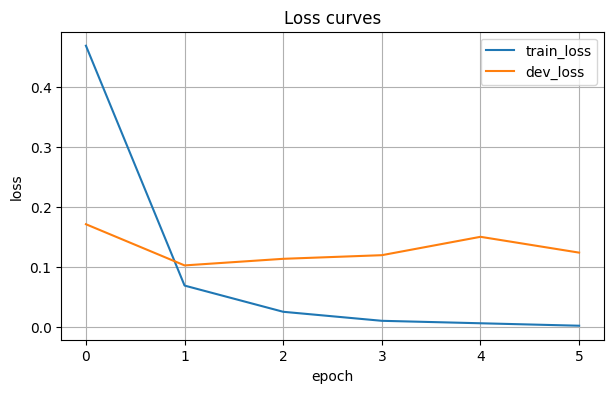

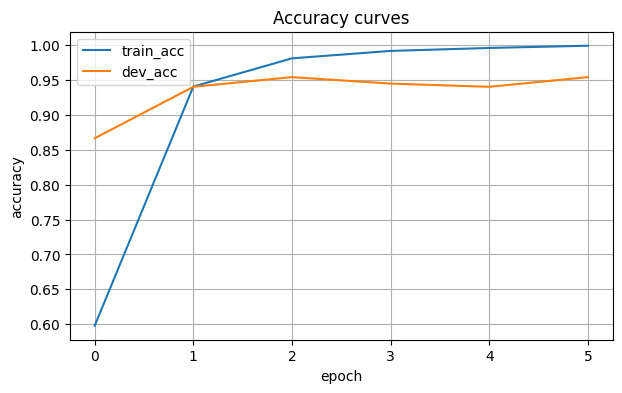

In [ ]:
# ============================================
# 10) Train / Eval
# ============================================
from sklearn.metrics import accuracy_score, f1_score

def run_eval(model, loader):
    model.eval()
    all_y, all_p = [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, attn, y in loader:
            x, attn, y = x.to(device), attn.to(device), y.to(device)
            logits, _ = model(x, attn)
            loss = criterion(logits, y)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_y.extend(y.detach().cpu().numpy().tolist())
            all_p.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(loader))
    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average="macro")
    return avg_loss, acc, f1m

EPOCHS = 20
PATIENCE = 3

history = {"train_loss":[], "train_acc":[], "dev_loss":[], "dev_acc":[], "dev_f1m":[]}

best_f1 = -1
pat = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    all_y, all_p = [], []

    for x, attn, y in train_loader:
        x, attn, y = x.to(device), attn.to(device), y.to(device)

        optimizer.zero_grad()
        logits, _ = model(x, attn)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_y.extend(y.detach().cpu().numpy().tolist())
        all_p.extend(preds.detach().cpu().numpy().tolist())

    train_loss = total_loss / max(1, len(train_loader))
    train_acc = accuracy_score(all_y, all_p)

    dev_loss, dev_acc, dev_f1m = run_eval(model, dev_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["dev_loss"].append(dev_loss)
    history["dev_acc"].append(dev_acc)
    history["dev_f1m"].append(dev_f1m)

    scheduler.step(dev_f1m)

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | dev loss {dev_loss:.4f} acc {dev_acc:.4f} f1m {dev_f1m:.4f}")

    # Early stopping on macro F1
    if dev_f1m > best_f1 + 1e-4:
        best_f1 = dev_f1m
        pat = 0
        best_path = os.path.join(SP_DIR, "best_custom_transformer.pt")
        torch.save(model.state_dict(), best_path)
        print("  ✅ best model saved:", best_path)
    else:
        pat += 1
        if pat >= PATIENCE:
            print("  ⏹️ early stopping")
            break

# Curves
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["dev_loss"], label="dev_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss curves"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["dev_acc"], label="dev_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy curves"); plt.legend(); plt.grid(True); plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


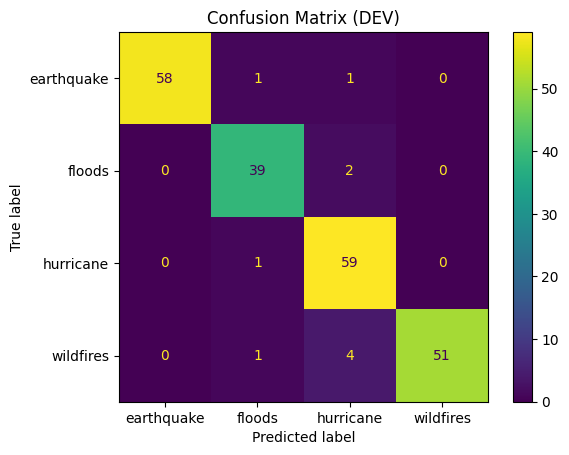

              precision    recall  f1-score   support

  earthquake     1.0000    0.9667    0.9831        60
      floods     0.9286    0.9512    0.9398        41
   hurricane     0.8939    0.9833    0.9365        60
   wildfires     1.0000    0.9107    0.9533        56

    accuracy                         0.9539       217
   macro avg     0.9556    0.9530    0.9531       217
weighted avg     0.9572    0.9539    0.9543       217



In [ ]:
# ============================================
# 11) Confusion matrix + report (DEV)
# ============================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# load best
best_path = os.path.join(SP_DIR, "best_custom_transformer.pt")
model.load_state_dict(torch.load(best_path, map_location=device))

def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, attn, y in loader:
            x, attn = x.to(device), attn.to(device)
            logits, _ = model(x, attn)
            preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
            ps.extend(preds)
            ys.extend(y.numpy().tolist())
    return np.array(ys), np.array(ps)

y_true, y_pred = predict_all(model, dev_loader)
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[ID2LABEL[i] for i in range(4)])
disp.plot(values_format="d")
plt.title("Confusion Matrix (DEV)")
plt.show()

print(classification_report(y_true, y_pred, target_names=[ID2LABEL[i] for i in range(4)], digits=4))

In [ ]:
# ============================================
# 12) Test evaluation
# ============================================
test_loss, test_acc, test_f1m = run_eval(model, test_loader)
print({"test_loss": test_loss, "test_acc": test_acc, "test_f1_macro": test_f1m})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.04950121724978089, 'test_acc': 0.9726027397260274, 'test_f1_macro': 0.9727576069405155}


In [ ]:
# ============================================
# 13) Save bundle for backend
# ============================================
EXPORT_DIR = os.path.join(SP_DIR, "final_custom_transformer_4class")
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), os.path.join(EXPORT_DIR, "model.pt"))

# Save SentencePiece model files
import shutil
shutil.copy2(SPM_MODEL_PATH, os.path.join(EXPORT_DIR, "spm.model"))
shutil.copy2(SPM_VOCAB_PATH, os.path.join(EXPORT_DIR, "spm.vocab"))

# Save config + label map
config = {
    "max_len": MAX_LEN,
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
    "arch": {
        "d_model": 256,
        "nhead": 8,
        "num_layers": 4,
        "dim_ff": 512,
        "dropout": 0.2
    }
}
with open(os.path.join(EXPORT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("✅ Exported to:", EXPORT_DIR)
print("Files:", os.listdir(EXPORT_DIR))

✅ Exported to: /content/drive/MyDrive/TASK01/models/task1b_custom_text/final_custom_transformer_4class
Files: ['spm.model', 'spm.vocab', 'model.pt', 'config.json']


In [ ]:
# ============================================
# 14) Load + inference (sanity test)
# ============================================
import sentencepiece as spm

def load_bundle(export_dir: str):
    # load config
    with open(os.path.join(export_dir, "config.json"), "r") as f:
        cfg = json.load(f)

    # load sentencepiece
    sp_local = spm.SentencePieceProcessor()
    sp_local.load(os.path.join(export_dir, "spm.model"))

    # rebuild model
    arch = cfg["arch"]
    mdl = DisasterTransformer(
        vocab_size=sp_local.get_piece_size(),
        num_classes=4,
        d_model=arch["d_model"],
        nhead=arch["nhead"],
        num_layers=arch["num_layers"],
        dim_ff=arch["dim_ff"],
        dropout=arch["dropout"],
        max_len=cfg["max_len"]
    ).to(device)

    mdl.load_state_dict(torch.load(os.path.join(export_dir, "model.pt"), map_location=device))
    mdl.eval()
    return cfg, sp_local, mdl

def predict_text(text: str, cfg, sp_local, mdl):
    text = preprocess_text(text)
    x, attn = encode_sp(text, max_len=cfg["max_len"])
    x = torch.tensor(x).unsqueeze(0).to(device)
    attn = torch.tensor(attn).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, _ = mdl(x, attn)
        probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
        pred = int(np.argmax(probs))

    return pred, probs

cfg2, sp2, mdl2 = load_bundle(EXPORT_DIR)

sample_texts = [
    "The wind is unbelievably strong right now.",
    "This hurricane is worse than expected.",
    "Trees falling everywhere after the cyclone hit.",
    "Hurricane winds destroy homes near the coast",
    "Water level rising fast in my area. It’s already knee deep.",
    "Heavy rain all night and now our ground floor is flooded.",
    "Lost electricity since morning because of the floods.",
    "Need clean drinking water urgently in this area.",
    "Wildfires spreading fast ne need help",
    "There is a lot of smoke and fire we cannot breath here",
    "We can see flames from our backyard",
    "Fire spreading fast because of strong winds.",
    "Road near the bridge has visible cracks now.",
    "Did anyone else just feel that?? My whole house shook for like 10 seconds 😳 #earthquake",
    "Flood water comming into hour house"
]

for t in sample_texts:
    pid, probs = predict_text(t, cfg2, sp2, mdl2)
    print("\nTEXT:", t)
    print("PRED:", ID2LABEL[pid])
    for i in range(4):
        print(f"  {ID2LABEL[i]:10s}: {probs[i]:.4f}")

/tmp/ipython-input-327/2931851454.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)



TEXT: The wind is unbelievably strong right now.
PRED: hurricane
  earthquake: 0.2634
  floods    : 0.0844
  hurricane : 0.5786
  wildfires : 0.0736

TEXT: This hurricane is worse than expected.
PRED: hurricane
  earthquake: 0.0510
  floods    : 0.0980
  hurricane : 0.8302
  wildfires : 0.0208

TEXT: Trees falling everywhere after the cyclone hit.
PRED: floods
  earthquake: 0.0471
  floods    : 0.6400
  hurricane : 0.2786
  wildfires : 0.0343

TEXT: Hurricane winds destroy homes near the coast
PRED: hurricane
  earthquake: 0.0261
  floods    : 0.0481
  hurricane : 0.8890
  wildfires : 0.0368

TEXT: Water level rising fast in my area. It’s already knee deep.
PRED: hurricane
  earthquake: 0.0741
  floods    : 0.2822
  hurricane : 0.6238
  wildfires : 0.0199

TEXT: Heavy rain all night and now our ground floor is flooded.
PRED: hurricane
  earthquake: 0.0161
  floods    : 0.0950
  hurricane : 0.8371
  wildfires : 0.0519

TEXT: Lost electricity since morning because of the floods.
PRED: h

In [ ]:
txt = preprocess_text("Massive wildfire spreading fast, evacuations underway")
print(txt)
print(sp.encode_as_pieces(txt))

massive wildfire spreading fast evacuations underway
['▁massive', '▁wildfire', '▁spread', 'ing', '▁f', 'ast', '▁evacuations', '▁under', 'way']
